In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

WORK_DIR = '/content/drive/MyDrive/assistant-radio'
base = pd.read_csv(f'{WORK_DIR}/results_baseline.csv')
impr = pd.read_csv(f'{WORK_DIR}/results_improved.csv')

print("Baseline :", base.shape, "| Improved :", impr.shape)
print("\nColonnes :", list(base.columns))
base.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Baseline : (30, 13) | Improved : (30, 13)

Colonnes : ['filename', 'path', 'true_class', 'predicted_class', 'correct', 'confidence', 'image_quality', 'visual_evidence', 'justification', 'limitations', 'json_valid', 'error', 'latency_s']


,filename,path,true_class,predicted_class,correct,confidence,image_quality,visual_evidence,justification,limitations,json_valid,error,latency_s
0,patient64576_view1_frontal.jpg,/content/chexpert/valid/patient64576/study1/vi...,normal,normal,1,0.95,good,The lungs appear clear with no obvious consoli...,The image shows a clear view of the chest with...,"The image is a single frontal view, which limi...",True,NaN,17.5
1,patient64599_view1_frontal.jpg,/content/chexpert/valid/patient64599/study1/vi...,normal,normal,1,0.90,good,The lungs appear relatively clear with no obvi...,"The image quality is good, allowing for a clea...","The image is a single frontal view, which limi...",True,NaN,17.8
2,patient64544_view1_frontal.jpg,/content/chexpert/valid/patient64544/study1/vi...,normal,normal,1,0.95,good,The lungs appear clear with no obvious consoli...,The image shows a clear view of the lungs and ...,"The image is a single frontal view, which limi...",True,NaN,22.9


In [8]:
from sklearn.metrics import f1_score, recall_score, confusion_matrix
import numpy as np
import pandas as pd

CLASSES = ["normal", "suspected_opacity", "uncertain"]

def metriques_bareme(df, name):
    y_true, y_pred = df["true_class"], df["predicted_class"]
    acc = (y_true == y_pred).mean()
    macro_f1 = f1_score(y_true, y_pred, labels=CLASSES, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, labels=CLASSES, average=None, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    spec = []
    for i in range(len(CLASSES)):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp; fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return {
        "variante": name,
        "accuracy": round(acc, 3),
        "macro_F1": round(macro_f1, 3),
        "sensibilite_macro": round(rec.mean(), 3),
        "specificite_macro": round(np.mean(spec), 3),
    }, rec, spec

res_base, rec_b, spec_b = metriques_bareme(base, "baseline")
res_impr, rec_i, spec_i = metriques_bareme(impr, "improved")

print("=== Metriques globales (bareme) ===")
print(pd.DataFrame([res_base, res_impr]).to_string(index=False))

print("\n=== Sensibilite (rappel) par classe ===")
print(pd.DataFrame({"classe": CLASSES, "baseline": rec_b.round(2), "improved": rec_i.round(2)}).to_string(index=False))

print("\n=== Specificite par classe ===")
print(pd.DataFrame({"classe": CLASSES, "baseline": np.round(spec_b, 2), "improved": np.round(spec_i, 2)}).to_string(index=False))

=== Metriques globales (bareme) ===
variante  accuracy  macro_F1  sensibilite_macro  specificite_macro
baseline       0.5     0.465                0.5               0.75
improved       0.4     0.299                0.4               0.70

=== Sensibilite (rappel) par classe ===
           classe  baseline  improved
           normal       0.9       0.9
suspected_opacity       0.3       0.0
        uncertain       0.3       0.3

=== Specificite par classe ===
           classe  baseline  improved
           normal      0.55       0.3
suspected_opacity      0.90       1.0
        uncertain      0.80       0.8


In [9]:
from sklearn.metrics import classification_report

for df, name in [(base, "BASELINE"), (impr, "IMPROVED")]:
    print(f"\n===== {name} =====")
    print(classification_report(df["true_class"], df["predicted_class"],
                                labels=CLASSES, zero_division=0, digits=2))


===== BASELINE =====
                   precision    recall  f1-score   support

           normal       0.50      0.90      0.64        10
suspected_opacity       0.60      0.30      0.40        10
        uncertain       0.43      0.30      0.35        10

         accuracy                           0.50        30
        macro avg       0.51      0.50      0.47        30
     weighted avg       0.51      0.50      0.47        30


===== IMPROVED =====
                   precision    recall  f1-score   support

           normal       0.39      0.90      0.55        10
suspected_opacity       0.00      0.00      0.00        10
        uncertain       0.43      0.30      0.35        10

         accuracy                           0.40        30
        macro avg       0.27      0.40      0.30        30
     weighted avg       0.27      0.40      0.30        30



In [3]:
import pandas as pd

def global_metrics(df, name):
    return {
        "variante": name,
        "accuracy": round(df["correct"].mean(), 3),
        "confiance_moyenne": round(df["confidence"].mean(), 3),
        "json_valides_%": round(df["json_valid"].mean() * 100, 1),
        "latence_moy_s": round(df["latency_s"].mean(), 1),
    }

summary = pd.DataFrame([
    global_metrics(base, "baseline"),
    global_metrics(impr, "improved"),
])
print(summary.to_string(index=False))

variante  accuracy  confiance_moyenne  json_valides_%  latence_moy_s
baseline       0.5              0.720           100.0           18.5
improved       0.4              0.663           100.0           17.4


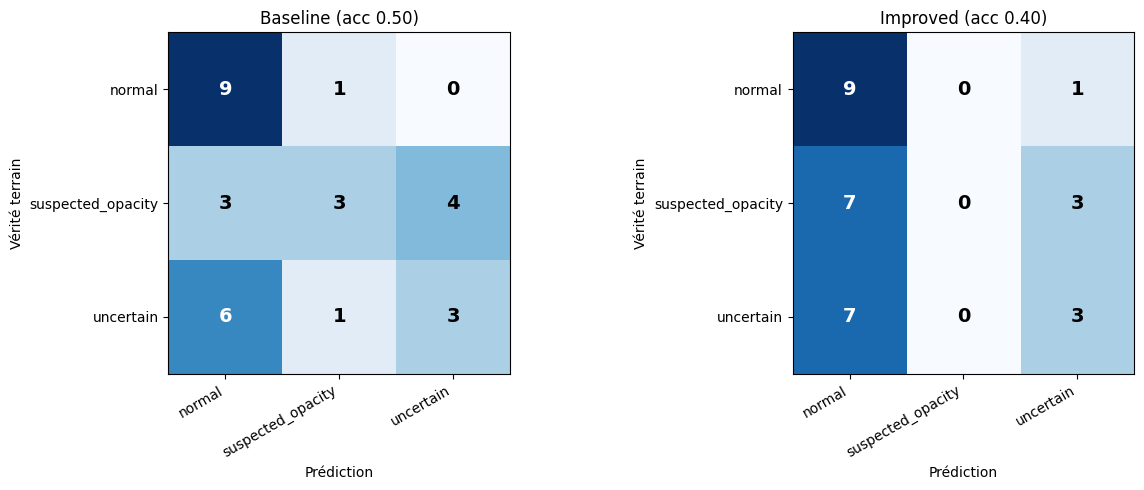

Lecture : la diagonale = bonnes réponses. Hors diagonale = erreurs.
Colonne 'normal' = nombre de cas classés normal par le modèle.


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

CLASSES = ["normal", "suspected_opacity", "uncertain"]

def plot_cm(ax, df, title):
    cm = confusion_matrix(df["true_class"], df["predicted_class"], labels=CLASSES)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASSES, rotation=30, ha="right")
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Prédiction"); ax.set_ylabel("Vérité terrain")
    ax.set_title(title)
    # Annoter chaque case avec le compte
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black",
                    fontsize=14, fontweight="bold")
    return cm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm_base = plot_cm(axes[0], base, f"Baseline (acc {base['correct'].mean():.2f})")
cm_impr = plot_cm(axes[1], impr, f"Improved (acc {impr['correct'].mean():.2f})")
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/confusion_matrices.png', dpi=120, bbox_inches="tight")
plt.show()

print("Lecture : la diagonale = bonnes réponses. Hors diagonale = erreurs.")
print("Colonne 'normal' = nombre de cas classés normal par le modèle.")

In [5]:
from sklearn.metrics import confusion_matrix
import pandas as pd

CLASSES = ["normal", "suspected_opacity", "uncertain"]

for df, name in [(base, "BASELINE"), (impr, "IMPROVED")]:
    cm = confusion_matrix(df["true_class"], df["predicted_class"], labels=CLASSES)
    print(f"\n=== {name} ===")
    print(pd.DataFrame(cm, index=[f"vrai_{c}" for c in CLASSES],
                       columns=[f"pred_{c}" for c in CLASSES]).to_string())


=== BASELINE ===
                        pred_normal  pred_suspected_opacity  pred_uncertain
vrai_normal                       9                       1               0
vrai_suspected_opacity            3                       3               4
vrai_uncertain                    6                       1               3

=== IMPROVED ===
                        pred_normal  pred_suspected_opacity  pred_uncertain
vrai_normal                       9                       0               1
vrai_suspected_opacity            7                       0               3
vrai_uncertain                    7                       0               3


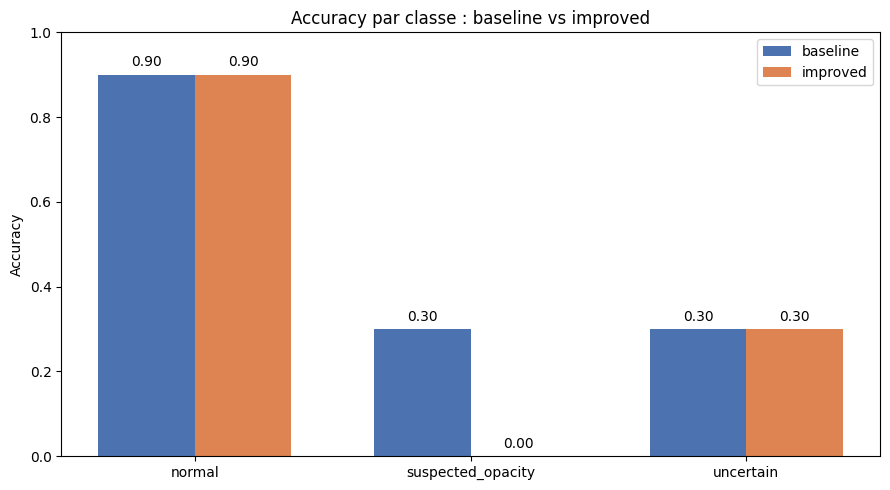

normal             | baseline 0.90 | improved 0.90
suspected_opacity  | baseline 0.30 | improved 0.00
uncertain          | baseline 0.30 | improved 0.30


In [6]:
import matplotlib.pyplot as plt
import numpy as np

CLASSES = ["normal", "suspected_opacity", "uncertain"]

def acc_per_class(df):
    return [df[df["true_class"] == c]["correct"].mean() for c in CLASSES]

acc_base = acc_per_class(base)
acc_impr = acc_per_class(impr)

x = np.arange(len(CLASSES))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, acc_base, w, label="baseline", color="#4C72B0")
ax.bar(x + w/2, acc_impr, w, label="improved", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
ax.set_title("Accuracy par classe : baseline vs improved")
ax.legend()
for i, (b, im) in enumerate(zip(acc_base, acc_impr)):
    ax.text(i - w/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=10)
    ax.text(i + w/2, im + 0.02, f"{im:.2f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/accuracy_par_classe.png', dpi=120, bbox_inches="tight")
plt.show()

for c, b, im in zip(CLASSES, acc_base, acc_impr):
    print(f"{c:18s} | baseline {b:.2f} | improved {im:.2f}")

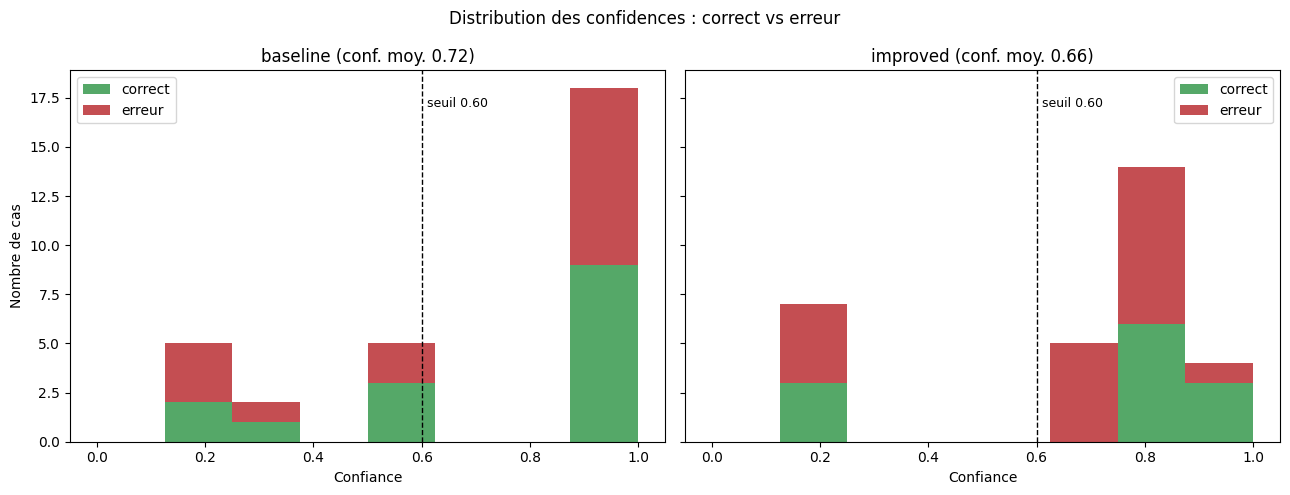

baseline  | conf. si correct : 0.73 | conf. si erreur : 0.71
improved  | conf. si correct : 0.69 | conf. si erreur : 0.65


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, df, name, color in [(axes[0], base, "baseline", "#4C72B0"),
                             (axes[1], impr, "improved", "#DD8452")]:
    # Confiances séparées : prédictions correctes vs erronées
    ok = df[df["correct"] == 1]["confidence"]
    ko = df[df["correct"] == 0]["confidence"]
    ax.hist([ok, ko], bins=8, range=(0, 1), stacked=True,
            color=["#55A868", "#C44E52"], label=["correct", "erreur"])
    ax.axvline(0.60, color="black", linestyle="--", linewidth=1)
    ax.text(0.61, ax.get_ylim()[1]*0.9, "seuil 0.60", fontsize=9)
    ax.set_title(f"{name} (conf. moy. {df['confidence'].mean():.2f})")
    ax.set_xlabel("Confiance"); ax.legend()
axes[0].set_ylabel("Nombre de cas")
plt.suptitle("Distribution des confidences : correct vs erreur")
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution_confidences.png', dpi=120, bbox_inches="tight")
plt.show()

# Confiance moyenne quand le modèle a raison vs quand il se trompe
for df, name in [(base, "baseline"), (impr, "improved")]:
    c_ok = df[df["correct"] == 1]["confidence"].mean()
    c_ko = df[df["correct"] == 0]["confidence"].mean()
    print(f"{name:9s} | conf. si correct : {c_ok:.2f} | conf. si erreur : {c_ko:.2f}")

## Exploitation des résultats — Notebook 2 (comparaison baseline vs improved)

### Tableau de synthèse

| Métrique | Baseline | Improved |
|----------|----------|----------|
| Accuracy globale | 0.50 | 0.40 |
| Confiance moyenne | 0.72 | 0.66 |
| JSON valides | 100 % | 100 % |
| Latence moyenne | 18.5 s | 17.4 s |

| Accuracy par classe | Baseline | Improved |
|---------------------|----------|----------|
| normal | 0.90 | 0.90 |
| suspected_opacity | 0.30 | 0.00 |
| uncertain | 0.30 | 0.30 |

| Calibration | Conf. si correct | Conf. si erreur | Écart |
|-------------|------------------|-----------------|-------|
| Baseline | 0.73 | 0.71 | 0.02 |
| Improved | 0.69 | 0.65 | 0.04 |

### Observation 1 — La différence est entièrement localisée sur une seule classe

Les deux variantes sont identiques sur `normal` (0.90) et sur `uncertain` (0.30).
La totalité de l'écart d'accuracy provient de la classe `suspected_opacity`, qui
passe de 0.30 (baseline) à **0.00** (improved). Le prompt amélioré a entièrement
supprimé la capacité du modèle à prédire `suspected_opacity` : les matrices de
confusion montrent que ces cas sont reclassés en `normal` (7 cas) ou `uncertain`
(3 cas). L'improved n'a donc pas « globalement régressé », il a éteint une classe.

### Observation 2 — La cause est une prudence excessive

La confiance moyenne baisse de 0.72 à 0.66 entre baseline et improved. Cela
confirme que les consignes du prompt amélioré (vérification des artefacts de
projection / rotation / exposition, et règle dure « confiance < 0.60 →
uncertain ») rendent le modèle nettement plus prudent. Cette prudence le pousse
à se réfugier dans la réponse perçue comme la plus sûre (`normal`) plutôt qu'à
signaler une anomalie. Cliniquement, ce comportement est contre-productif :
manquer une opacité (faux négatif) est plus grave que la sur-signaler.

### Observation 3 — La prudence n'apporte pas de gain de fiabilité mesurable

La calibration mesure si le modèle « sait quand il sait » : l'écart entre la
confiance sur les réponses correctes et sur les erreurs. Les deux variantes sont
mal calibrées (écart de 0.02 pour baseline, 0.04 pour improved) : dans les deux
cas, le modèle est presque aussi confiant lorsqu'il se trompe que lorsqu'il a
raison. L'improved sépare très légèrement mieux ses succès de ses erreurs, mais
sur 30 cas cet écart n'est pas statistiquement significatif et ne permet pas de
conclure à une meilleure fiabilité.

### Observation 4 — Limite de protocole sur la classe `uncertain`

Les deux variantes plafonnent à 0.30 sur `uncertain`. Cette classe provient de
notre mapping des étiquettes CheXpert (cas qui n'étaient ni `No Finding` ni
`Lung Opacity`) et non d'une incertitude visuelle réelle. Le modèle n'a donc
aucun signal visuel pour la prédire. Cette métrique mesure en partie un artefact
de construction des étiquettes, ce qui en limite l'interprétation.

### Conclusion et piste d'amélioration

Sur ce jeu de test de 30 cas, le prompt amélioré échange de la sensibilité (perte
totale de la détection d'opacités) contre une prudence accrue, sans gain de
fiabilité mesurable. Le diagnostic est clair : la règle de seuil « confiance
0.60 → uncertain » est **trop agressive** et devrait être recalibrée (par exemple
abaissée à 0.40, ou remplacée par une règle ne s'appliquant pas à la classe
`suspected_opacity`). Cette recalibration constitue la prochaine itération
naturelle pour transformer la prudence de l'improved en réelle amélioration
mesurable, sans sacrifier la détection des anomalies.

### Limites générales

Échantillon de 30 cas (résultats indicatifs, non statistiquement robustes) ;
classe `uncertain` issue du mapping et non d'une incertitude clinique ; vérité
terrain CheXpert simplifiée à 3 classes ; modèle non validé cliniquement.
Prototype strictement pédagogique.